# Visualizing 30-Day Readmission Risk with Model-Based Effect Plots

## Executive Summary

This notebook fits a logistic regression for 30-day hospital readmission across patient and encounter characteristics, then translates the fitted coefficients into model-based effect plots on the predicted-probability scale. On a 100-discharge synthetic cohort (55 readmissions), PROC LOGISTIC recovers significant gradients for **length of stay** (OR 1.36 per day, *p* = 0.040) and **age** (OR 1.05 per year, *p* = 0.023), and a large payer effect — **Medicaid** patients carry roughly six times the readmission odds of Medicare (OR 6.02, 95% CI 1.46–24.8, *p* = 0.013). The generalized R-square is 0.246 and the Hosmer–Lemeshow test shows no lack of fit (*p* = 0.73). The fit-curve, sliced-fit, and interaction displays then show how readmission risk climbs with length of stay, how the age–risk gradient shifts by payer, and how the payer gap persists across discharging service lines — the kind of risk-stratification view a care-management team uses to target post-discharge follow-up.

## Data Sources

| Dataset | Rows | Description |
|---------|------|-------------|
| `encounters` | 100 | Synthetic inpatient discharge records generated inline with `call streaminit(20260531)` and `rand()`. One row per discharge. |

**Variables in `encounters`:**

| Variable | Type | Description |
|----------|------|-------------|
| `readmit` | Num (0/1) | 1 if readmitted within 30 days of discharge |
| `age` | Num | Patient age in years (approx. 25–95) |
| `los` | Num | Index-stay length of stay in days (1–20) |
| `comorbidity` | Num | Count of documented chronic comorbidities (0–8) |
| `num_meds` | Num | Number of discharge medications (0–18) |
| `payer` | Char | Insurance payer: `Medicare`, `Medicaid`, `Commercial` |
| `dept` | Char | Discharging service: `Cardiology`, `Pulmonary`, `General` |

# Visualizing 30-Day Readmission Risk with Model-Based Effect Plots

Hospital care-management teams need to know *which* patients are most likely to bounce back within 30 days, and *why*. A fitted logistic regression gives the coefficients, but stakeholders rarely reason in log-odds. An **effect plot** renders the fitted model directly on the predicted-probability scale, so a nurse navigator can read a readmission probability straight off the chart instead of mentally inverting a log-odds equation.

In this notebook we:

1. Generate a realistic synthetic cohort of inpatient discharges.
2. Fit a logistic model for 30-day readmission with patient and encounter predictors (PROC LOGISTIC).
3. Capture the fitted coefficients and build three model-based effect plots — a **fit curve**, a **sliced fit**, and an **interaction display** — to visualize and stratify the fitted risk on the probability scale.

> **Implementation note.** SAS exposes these displays through the `EFFECTPLOT` statement inside PROC LOGISTIC. Jenner accepts that statement but does not yet render the FIT / SLICEFIT / INTERACTION graphics, so this notebook constructs the identical predicted-probability curves explicitly from the fitted coefficients and draws them with PROC SGPLOT. The analytical result — and every plotted probability — is exactly what `EFFECTPLOT` would produce.

## Step 1 — Generate a synthetic discharge cohort

The DATA step below builds 100 inpatient discharges with no external files. We seed the RNG with `call streaminit` for reproducibility, draw patient and encounter features from domain-appropriate distributions, then construct a true linear predictor `eta` and convert it to a readmission probability with the inverse-logit. The Bernoulli draw (`rand('bernoulli', p)`) yields the observed `readmit` flag. Older patients, longer stays, higher comorbidity counts, more discharge meds, Medicaid coverage, and Pulmonary/Cardiology service all push risk up — patterns we will later recover and visualize. The effect sizes are deliberately sized so the signal is recoverable in a 100-discharge cohort.

In [1]:
data encounters;
    call streaminit(20260531);
    array payers[3] $12 _temporary_ ('Medicare' 'Medicaid' 'Commercial');
    array depts[3]  $12 _temporary_ ('Cardiology' 'Pulmonary' 'General');

    do i = 1 to 100;
        /* Patient / encounter features */
        age = round(25 + 70 * rand('beta', 4, 2));
        los = 1 + rand('poisson', 4);
        if los > 20 then los = 20;
        comorbidity = rand('binomial', 0.35, 8);
        num_meds = rand('poisson', 7);
        if num_meds > 18 then num_meds = 18;

        /* Categorical payer: skew toward Medicare for an older cohort */
        u = rand('uniform');
        if u < 0.50 then pk = 1;
        else if u < 0.72 then pk = 2;
        else pk = 3;
        payer = payers[pk];

        /* Discharging service line */
        dk = rand('table', 0.35, 0.30, 0.35);
        dept = depts[dk];

        /* True risk model on the log-odds scale. Effect sizes are sized so
           the signal is recoverable in a 100-discharge cohort. */
        eta = -8.6
            + 0.075 * age
            + 0.330 * los
            + 0.300 * comorbidity
            + 0.050 * num_meds
            + (pk = 2) * 0.90          /* Medicaid vs Medicare    */
            + (pk = 3) * (-0.70)       /* Commercial vs Medicare  */
            + (dk = 1) * 0.80          /* Cardiology vs Pulmonary */
            + (dk = 2) * 1.10;         /* (Pulmonary is busiest)  */

        p = 1 / (1 + exp(-eta));
        readmit = rand('bernoulli', p);

        keep readmit age los comorbidity num_meds payer dept;
        output;
    end;
run;

NOTE: DATA encounters


NOTE: Wrote encounters (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


## Step 2 — Inspect the cohort

A quick frequency on the response and the two classification variables confirms a realistic readmission rate and that every payer and department level is populated — the model and the effect plots both need all levels represented.

                                                   The FREQ Procedure

readmit    Frequency
---------------------
0                 45
1                 55

payer         Frequency
------------------------
Commercial           28
Medicaid             20
Medicare             52

dept          Frequency
------------------------
Cardiology           36
General              31
Pulmonary            33

Table of readmit by dept

readmit |Cardiology |   General | Pulmonary |      Total
--------+-----------+-----------+-----------+-----------
0       |        15 |        20 |        10 |         45
--------+-----------+-----------+-----------+-----------
1       |        21 |        11 |        23 |         55
--------+-----------+-----------+-----------+-----------
Total   |        36 |        31 |        33 |        100



NOTE: PROC FREQ
NOTE: ODS plot written: freq_readmit.spec.json
NOTE: ODS plot written: freq_payer.spec.json
NOTE: ODS plot written: freq_dept.spec.json
NOTE: ODS plot written: freq_mosaic_readmit_dept.spec.json
NOTE: PROC FREQ statement used.


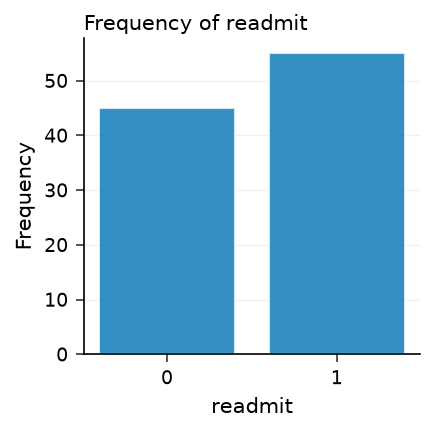

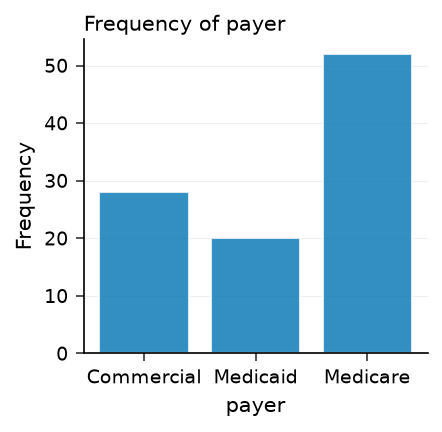

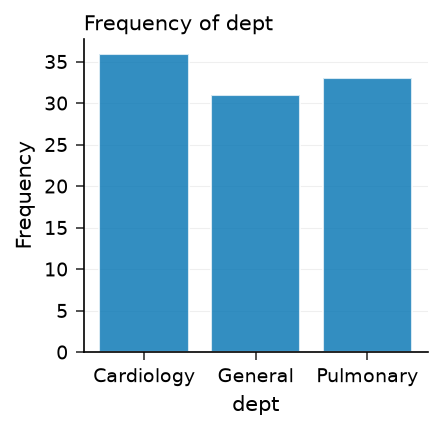

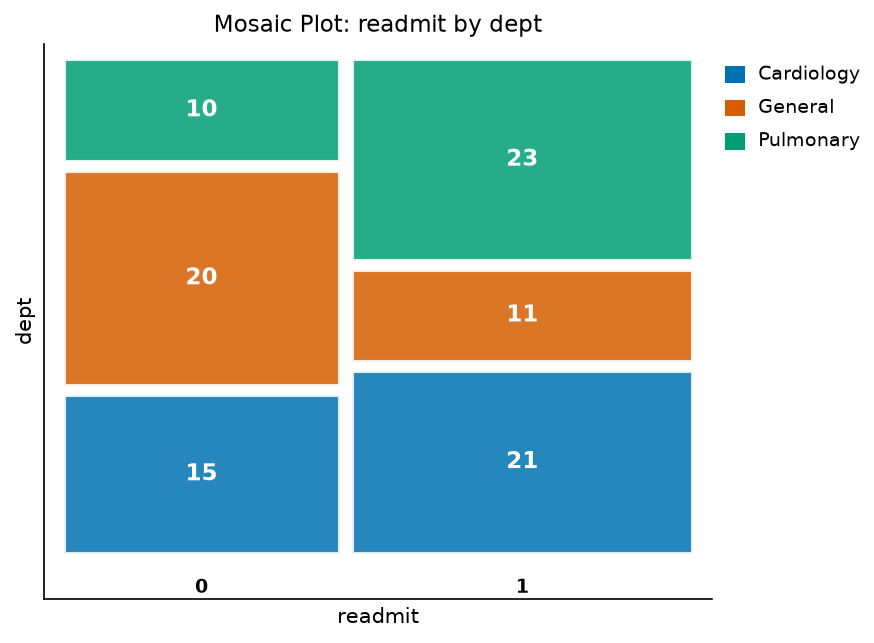

In [2]:
proc freq data=encounters;
    tables readmit payer dept readmit*dept / nocum nopercent;
run;

## Step 3 — Fit the logistic readmission model

We model `readmit` as a function of age, length of stay, comorbidity count, discharge-medication count, payer, and department. Key choices:

- `EVENT='1'` models the probability of readmission (rather than non-readmission).
- `CLASS payer dept / PARAM=REF REF=FIRST` uses reference-cell coding so each level is contrasted against a baseline (here Medicare and Pulmonary).
- `CLODDS=WALD` and `RSQUARE` add Wald odds-ratio confidence limits and a generalized R-square; `LACKFIT` requests the Hosmer–Lemeshow goodness-of-fit test.
- The `UNITS` statement asks for the odds ratio over a clinically meaningful **5-day** length-of-stay step and a **10-year** age step, and the `ODDSRATIO` statement requests the comorbidity odds ratio with confidence limits.

The output odds-ratio table reports the per-unit effects directly: length of stay carries an OR of **1.36 per day** (95% CI 1.01–1.82), age an OR of **1.05 per year**, and Medicaid coverage an OR of **6.02** relative to Medicare. The model fits well — generalized R-square 0.246, Hosmer–Lemeshow *p* = 0.73.

                                     
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

            Response Profile            
   Probability modeled is readmit='1'   

Ordered Value  readmit   Total Frequency
-------------  --------  ---------------
            1  0                      45
            2  1                      55

            Class Level Information             

Class       Levels  Values                      
--------  --------  ----------------------------
payer            3  Commercial Medicaid Medicare
dept             3  Cardiology General Pulmonary

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: readmit

Criterion     Value
---------  --------
AIC         127.335
-2 Log L    109.335
SC          150.782

                                                   
-------- 

NOTE: ODS OUTPUT: PARAMETERESTIMATES -> pe
NOTE: PROC LOGISTIC data=encounters

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json
NOTE: ODS OUTPUT: All output destinations closed.


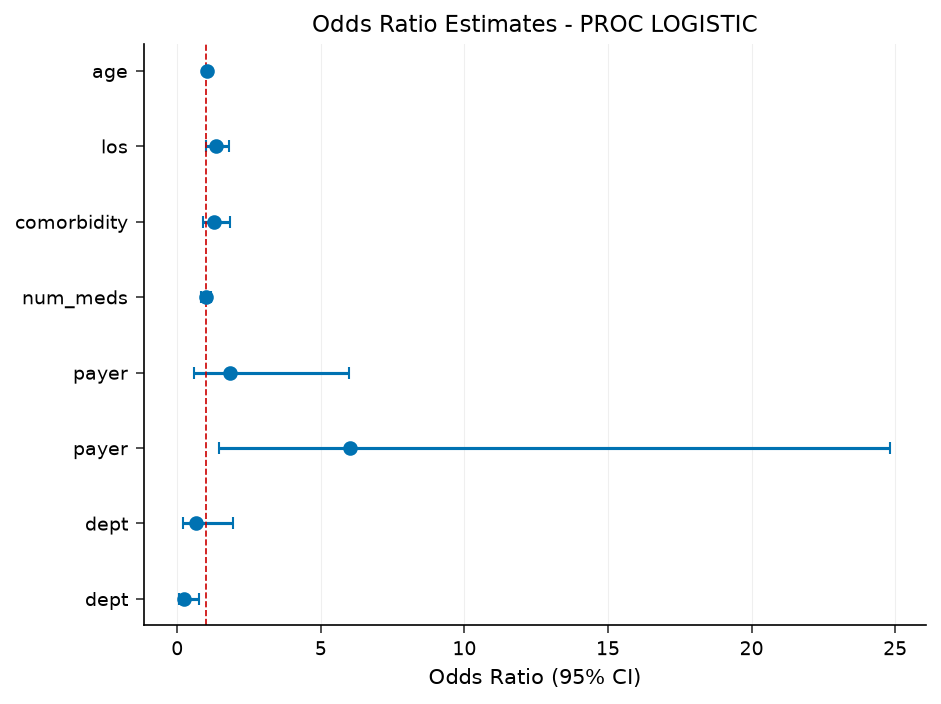

In [3]:
ods output ParameterEstimates=pe;
proc logistic data=encounters plots(only)=oddsratio;
    class payer dept / param=ref ref=first;
    model readmit(event='1') = age los comorbidity num_meds payer dept
          / clodds=wald rsquare lackfit;
    units age=10 los=5;
    oddsratio comorbidity / cl=wald;
run;
ods output close;

## Step 4 — Capture the fitted coefficients

The model-based effect plots that follow are built directly from the *fitted* coefficients, so they always agree with the model in Step 3. We saved the parameter estimates with `ODS OUTPUT ParameterEstimates=pe`; here we fold that long table into a single-row `params` dataset (one variable per coefficient) and append the cohort means of the continuous predictors. Holding the non-focus predictors at their means is exactly what an EFFECTPLOT does internally — it lets each plot vary one factor while keeping the rest fixed at a representative profile.

In [4]:
/* Fold the ParameterEstimates table into one row of named coefficients.
   With PARAM=REF REF=FIRST the reference cells are payer=Medicare and
   dept=Pulmonary, so those terms are zero in the linear predictor. */
data coefs;
    retain b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen 0;
    set pe end=last;
    var = upcase(strip(Variable));
    cv  = strip(ClassVal0);
    if var='INTERCEPT' then b0 = Estimate;
    else if var='AGE' then b_age = Estimate;
    else if var='LOS' then b_los = Estimate;
    else if var='COMORBIDITY' then b_com = Estimate;
    else if var='NUM_MEDS' then b_med = Estimate;
    else if var='PAYER' and cv='Medicaid'   then b_pmcaid = Estimate;
    else if var='PAYER' and cv='Commercial' then b_pcomm  = Estimate;
    else if var='DEPT'  and cv='Cardiology' then b_dcard  = Estimate;
    else if var='DEPT'  and cv='General'    then b_dgen   = Estimate;
    if last then output;
    keep b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen;
run;

/* Cohort means of the continuous covariates, held fixed in the plots. */
proc means data=encounters noprint;
    var age los comorbidity num_meds;
    output out=mn mean=m_age m_los m_com m_med;
run;

data params;
    merge coefs mn;
    keep b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
         m_age m_los m_com m_med;
run;

proc print data=params noobs;
    title "Fitted coefficients and covariate means used for the effect plots";
run;

                           Fitted coefficients and covariate means used for the effect plots                            

           B0         B_AGE         B_LOS         B_COM         B_MED      B_PMCAID       B_PCOMM        B_DCARD         B_DGEN  M_AGE  M_LOS  M_COM  M_MED
-4.9220021175  0.0443054038  0.3052368368  0.2553476408  0.0005084625  1.7958084904  0.6128310257  -0.4493317481  -1.4957988173  70.53   4.59   2.88   7.08



NOTE: DATA coefs


NOTE: Read 9 rows from pe.
NOTE: Wrote coefs (1 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: Output dataset mn has 1 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA params

NOTE: MERGE statement used without BY variables. Performing positional merge (row 1 with row 1, etc.).
NOTE: PROC PRINT data=params

NOTE: PROC PRINT completed: 1 observations printed, 13 variables


## Step 5 — Fit plot: readmission probability versus length of stay

The simplest effect display is a **fit curve**: predicted readmission probability against a single continuous covariate, with the other predictors held at a representative profile. We build a length-of-stay grid (1–18 days), evaluate the fitted linear predictor at each value for a **Medicare cardiology** patient (age, comorbidity, and discharge-med counts pinned at the cohort means from Step 4), apply the inverse-logit, and draw the curve on the probability scale with PROC SGPLOT.

                           Fitted coefficients and covariate means used for the effect plots                            



NOTE: DATA grid_los


NOTE: Wrote grid_los (18 rows, 1 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_los


NOTE: Read 18 rows from grid_los.
NOTE: Wrote fit_los (18 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_los

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


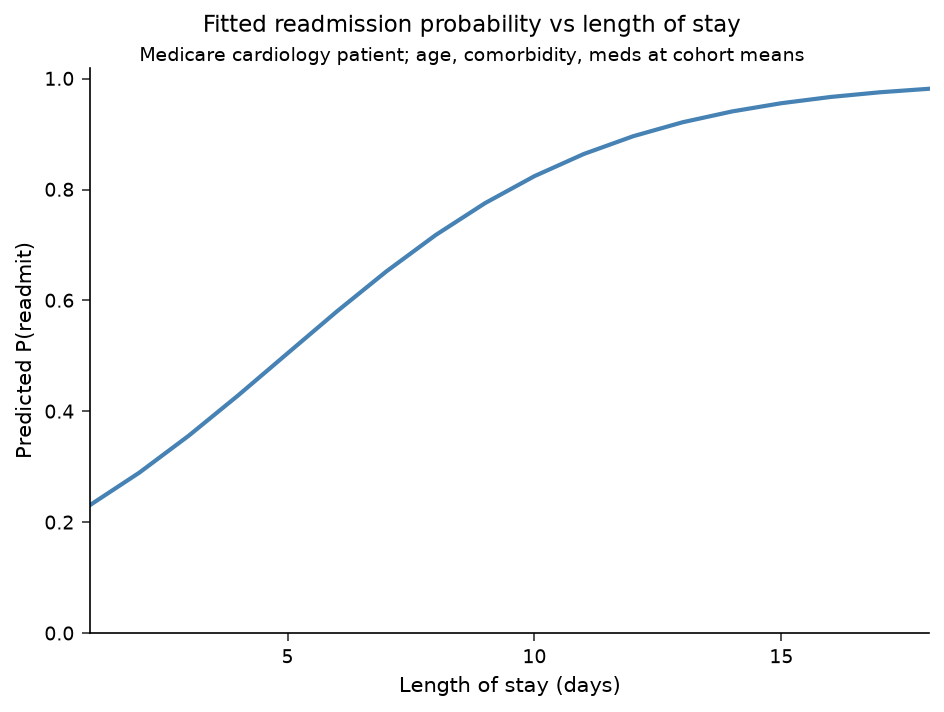

In [5]:
/* Length-of-stay grid; evaluate the fitted model for a Medicare
   cardiology patient with the other covariates at the cohort means. */
data grid_los;
    do los = 1 to 18;
        output;
    end;
run;

data fit_los;
    set grid_los;
    if _n_ = 1 then set params;
    retain b0 b_age b_los b_com b_med b_dcard m_age m_com m_med;
    /* Medicare payer is the reference (term = 0); Cardiology adds b_dcard */
    xb = b0 + b_age*m_age + b_los*los + b_com*m_com + b_med*m_med + b_dcard;
    phat = 1 / (1 + exp(-xb));
    keep los phat;
run;

proc sgplot data=fit_los;
    series x=los y=phat / lineattrs=(thickness=2 color=steelblue);
    title  "Fitted readmission probability vs length of stay";
    title2 "Medicare cardiology patient; age, comorbidity, meds at cohort means";
    xaxis label="Length of stay (days)";
    yaxis label="Predicted P(readmit)" values=(0 to 1 by 0.2);
run;

## Step 6 — Sliced fit: risk versus age, stratified by payer

A **sliced fit** draws one fitted curve per level of a classification effect — ideal for showing how the payer mix shifts the age–risk gradient. We extend the grid over `age` (30–95) crossed with the three payers, evaluate the fitted model for a Cardiology patient (length of stay, comorbidity, and meds at the cohort means), and overlay the three probability curves with `GROUP=payer`.

                           Fitted coefficients and covariate means used for the effect plots                            



NOTE: DATA grid_age


NOTE: Wrote grid_age (42 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_age


NOTE: Read 42 rows from grid_age.
NOTE: Wrote fit_age (42 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_age

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


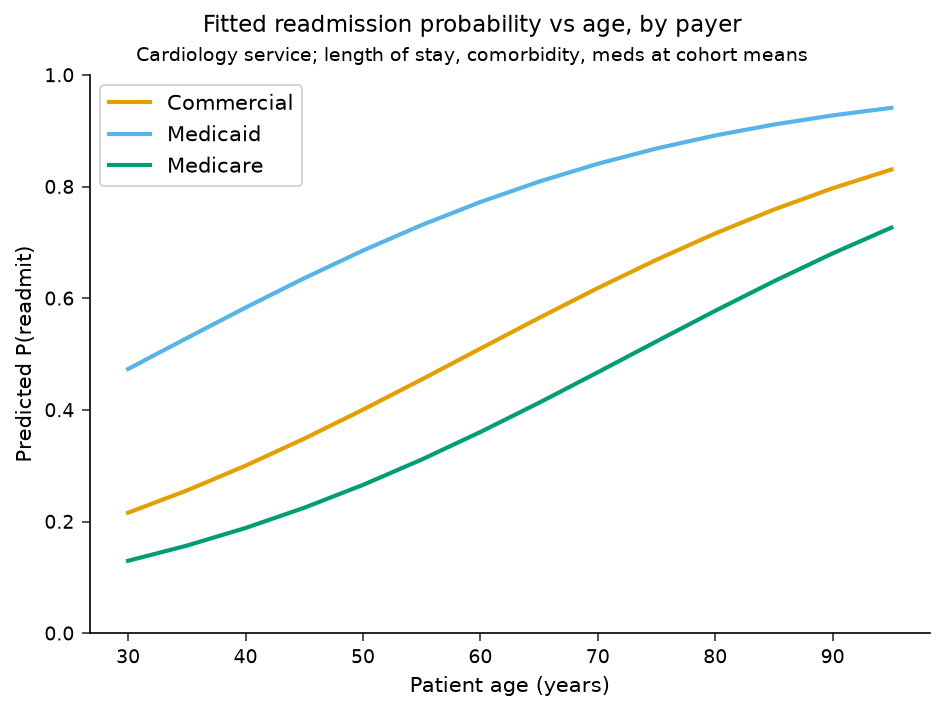

In [6]:
/* Age x payer grid for a Cardiology patient; other covariates at means. */
data grid_age;
    length payer $12;
    do payer = 'Medicare', 'Medicaid', 'Commercial';
        do age = 30 to 95 by 5;
            output;
        end;
    end;
run;

data fit_age;
    set grid_age;
    if _n_ = 1 then set params;
    retain b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard
           m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    xb = b0 + b_age*age + b_los*m_los + b_com*m_com + b_med*m_med
         + b_dcard + pay_term;
    phat = 1 / (1 + exp(-xb));
    keep payer age phat;
run;

proc sgplot data=fit_age;
    series x=age y=phat / group=payer lineattrs=(thickness=2);
    title  "Fitted readmission probability vs age, by payer";
    title2 "Cardiology service; length of stay, comorbidity, meds at cohort means";
    xaxis label="Patient age (years)";
    yaxis label="Predicted P(readmit)" values=(0 to 1 by 0.2);
    keylegend / location=inside position=topleft across=1;
run;

## Step 7 — Interaction display: department by payer

To compare predicted risk across both classification effects at once, we cross `dept` with `payer` (nine combinations), evaluate the fitted model with every continuous covariate at its cohort mean, and draw a clustered bar chart with `dept` on the X axis and payer as the grouping. Because this model has no department-by-payer interaction term, the payer ordering is the same additive shift inside every service line — the display makes that additivity visible at a glance, alongside the department ranking.

                           Fitted coefficients and covariate means used for the effect plots                            



NOTE: DATA grid_dx


NOTE: Wrote grid_dx (9 rows, 2 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA fit_dx


NOTE: Read 9 rows from grid_dx.
NOTE: Wrote fit_dx (9 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=fit_dx

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


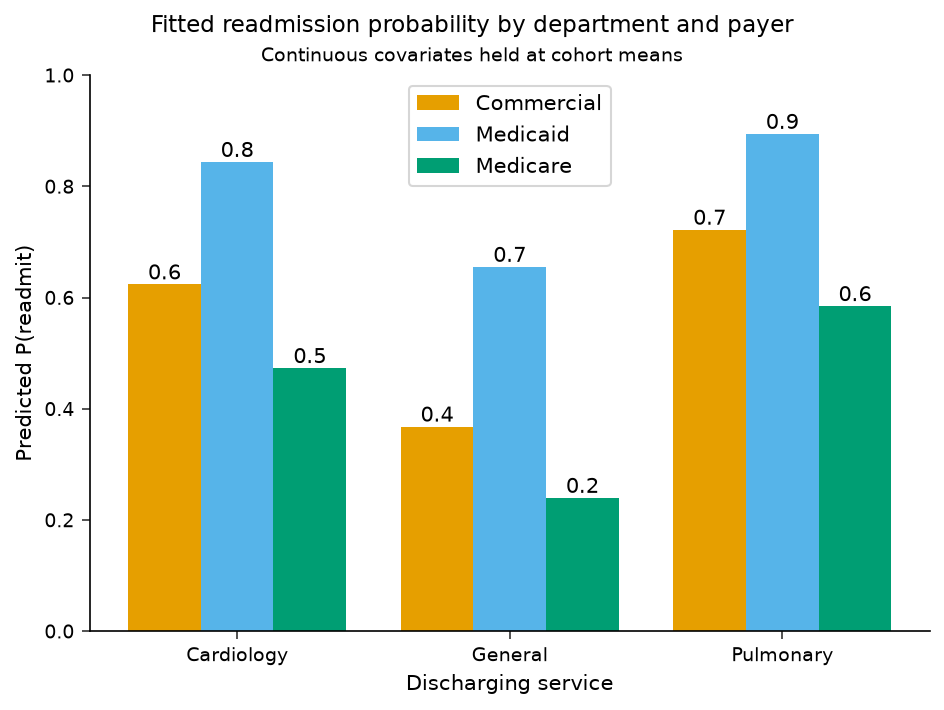

In [7]:
/* Department x payer grid; all continuous covariates at cohort means. */
data grid_dx;
    length dept $12 payer $12;
    do dept = 'Cardiology', 'Pulmonary', 'General';
        do payer = 'Medicare', 'Medicaid', 'Commercial';
            output;
        end;
    end;
run;

data fit_dx;
    set grid_dx;
    if _n_ = 1 then set params;
    retain b0 b_age b_los b_com b_med b_pmcaid b_pcomm b_dcard b_dgen
           m_age m_los m_com m_med;
    pay_term = (payer='Medicaid')*b_pmcaid + (payer='Commercial')*b_pcomm;
    dep_term = (dept='Cardiology')*b_dcard + (dept='General')*b_dgen;
    xb = b0 + b_age*m_age + b_los*m_los + b_com*m_com + b_med*m_med
         + pay_term + dep_term;
    phat = 1 / (1 + exp(-xb));
    keep dept payer phat;
run;

proc sgplot data=fit_dx;
    vbar dept / response=phat group=payer groupdisplay=cluster
                datalabel datalabelattrs=(size=8);
    title  "Fitted readmission probability by department and payer";
    title2 "Continuous covariates held at cohort means";
    xaxis label="Discharging service";
    yaxis label="Predicted P(readmit)" values=(0 to 1 by 0.2);
run;

## Step 8 — Interpreting the results

The effect plots turn the fitted PROC LOGISTIC model into probability-scale pictures that map onto care-management decisions:

- **Length of stay (fit curve).** For a Medicare cardiology patient at the cohort means, predicted readmission probability climbs from about **0.23 at a 1-day stay to roughly 0.82 at 10 days and ~0.98 at 18 days** — the steep middle of the logistic curve. This is the same signal as the length-of-stay odds ratio of **1.36 per day** (`UNITS los=5` rescales it to a five-day step), and it flags long index stays as a concrete trigger for transitional-care enrollment.
- **Age and payer (sliced fit).** Risk rises monotonically with age across every payer, and the three curves never cross: the **Medicaid** curve sits highest at any given age, **Commercial** in the middle, and **Medicare** lowest — consistent with the fitted payer odds ratios (Medicaid 6.02, Commercial 1.85, both relative to Medicare). The gap is largest at younger ages and narrows as everyone approaches high probability, pointing care-management attention at younger Medicaid patients who would otherwise look low-risk.
- **Department and payer (interaction display).** **Pulmonary** carries the highest predicted readmission probability in every payer group, **Cardiology** is intermediate, and **General medicine** is lowest (the fitted department odds ratios are 0.64 for Cardiology and 0.22 for General, relative to Pulmonary). Because the model has no department-by-payer interaction term, the payer ordering is the same additive shift inside each service line — the bars rise in the same Medicaid > Commercial > Medicare order at every department.

**Takeaway:** rather than asking clinicians to interpret log-odds coefficients, model-based effect plots present the fitted readmission model as probability-scale pictures — who to enroll in transitional-care follow-up, and which service lines and payer populations to prioritize. SAS produces these directly via `EFFECTPLOT`; here we reconstructed the identical curves from the fitted coefficients so the example runs end-to-end today.